In [ ]:
# Import required library
import pandas as pd
import polars as pl
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
from statsmodels.miscmodels.ordinal_model import OrderedModel

# Check whether the packages for pandas, polars and numpy have been properly imported into the enviroment
print(pd.__version__)
print(pl.__version__)
print(np.__version__)

3.0.5
1.44.1
2.5.3


In [31]:
# Import Dataset
sleep_data = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

# Quick data exploration to see the first 3 rows and last 3 rows of the dataset
print(sleep_data.head(3))
print(sleep_data.tail(3))

   Person ID Gender  Age         Occupation  Sleep Duration  Quality of Sleep  \
0          1   Male   27  Software Engineer             6.1                 6   
1          2   Male   28             Doctor             6.2                 6   
2          3   Male   28             Doctor             6.2                 6   

   Physical Activity Level  Stress Level BMI Category Blood Pressure  \
0                       42             6   Overweight         126/83   
1                       60             8       Normal         125/80   
2                       60             8       Normal         125/80   

   Heart Rate  Daily Steps Sleep Disorder  
0          77         4200            NaN  
1          75        10000            NaN  
2          75        10000            NaN  
     Person ID  Gender  Age Occupation  Sleep Duration  Quality of Sleep  \
371        372  Female   59      Nurse             8.1                 9   
372        373  Female   59      Nurse             8.1    

In [7]:
# Check the number of rows and columns in the dataset
print(sleep_data.shape)

# View the column names
print(sleep_data.columns)

(374, 13)
Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='str')


In [8]:
# View the data type and missing data
print(sleep_data.info())

# View summary statistics of the dataset
print(sleep_data.describe())

<class 'pandas.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    str    
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    str    
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    str    
 9   Blood Pressure           374 non-null    str    
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    str    
dtypes: float64(1), int64(7), str(5)
memory usage: 38.1 KB
None
        Person ID         Age  S

In [ ]:
# Check for duplicated value under 'Person ID'
print(f'Number of duplicates: {sleep_data["Person ID"].duplicated().sum()}')

# View category under the column "Sleep Disorder"
print(sleep_data["Sleep Disorder"].value_counts(dropna=False))

# View rows with missing data
sleep_data[sleep_data["Sleep Disorder"].isnull()]

Number of duplicates: 0
Sleep Disorder
NaN            219
Sleep Apnea     78
Insomnia        77
Name: count, dtype: int64


,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
341,342,Female,56,Doctor,8.2,9,90,3,Normal Weight,118/75,65,10000,NaN
342,343,Female,56,Doctor,8.2,9,90,3,Normal Weight,118/75,65,10000,NaN
343,344,Female,57,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,NaN
358,359,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,NaN


In [ ]:
# Create a new categorical column to show the level of daily step between Low, Medium and High
sleep_data["Daily Step Level"] = sleep_data["Daily Steps"].apply(
    lambda x: "Low" if x <= 5600 else "Medium" if x < 8000 else "High"
)
print(sleep_data["Daily Step Level"].value_counts(dropna=False))

# Create a new subset of data only for those with Medium and High daily step for comparison
sleep_data_analysis = sleep_data[
    sleep_data["Daily Step Level"].isin(["Low", "High"])
]

Daily Step Level
Medium    142
High      137
Low        95
Name: count, dtype: int64


In [108]:
# Use .groupby() to compute summary statistics of Sleep Duration and Stress Level
sleep_data_analysis.groupby("Daily Step Level").agg(
    {
        "Person ID": "nunique",
        "Sleep Duration": ["mean", "median"],
        "Stress Level": ["mean", "median"]
    }
)

Person ID Sleep Duration        Stress Level       
                   nunique           mean median         mean median
Daily Step Level                                                    
High                   137       7.159854    7.5     6.043796    6.0
Low                     95       7.155789    6.9     5.431579    5.0

In [120]:
# Machine Learning Algorithm
# Scenario 1 - Sleep Duration vs Daily Steps
# We want to see if daily steps can predict hours of sleep. 
x1 = sleep_data[["Daily Steps"]]
y1 = sleep_data["Sleep Duration"]

# Perform random split between the train and test data set. Here we are testing 20% of the data.
x1_train, x1_test, y1_train, y1_test = train_test_split(
    x1, y1, test_size=0.2, random_state=100
)

# Model 1: Linear Regression
model1 = LinearRegression()
model1.fit(x1_train, y1_train)
y1_m1_pred = model1.predict(x1_test)
print("R² from Linear Regression:", r2_score(y1_test, y1_m1_pred))
print("RMSE from Linear Regression:", np.sqrt(mean_squared_error(y1_test, y1_m1_pred)))

# Model 2: Decision Tree Regression
model2 = DecisionTreeRegressor(random_state=100)
model2.fit(x1_train, y1_train)
y1_m2_pred = model2.predict(x1_test)
print("R² from Decision Tree Regression:", r2_score(y1_test, y1_m2_pred))
print("RMSE from Decision Tree Regression:", np.sqrt(mean_squared_error(y1_test, y1_m2_pred)))

# Model 3: Random Forest Regression
model3 = RandomForestRegressor(random_state=100)
model3.fit(x1_train, y1_train)
y1_m3_pred = model3.predict(x1_test)
print("R² from Random Forest Regression:", r2_score(y1_test, y1_m3_pred))
print("RMSE from Random Forest Regression:", np.sqrt(mean_squared_error(y1_test, y1_m3_pred)))

R² from Linear Regression: -0.0008729808263150396
RMSE from Linear Regression: 0.7932029988402829
R² from Decision Tree Regression: 0.6002450704064584
RMSE from Decision Tree Regression: 0.5012931599227941
R² from Random Forest Regression: 0.6045819466856123
RMSE from Random Forest Regression: 0.4985665205178498


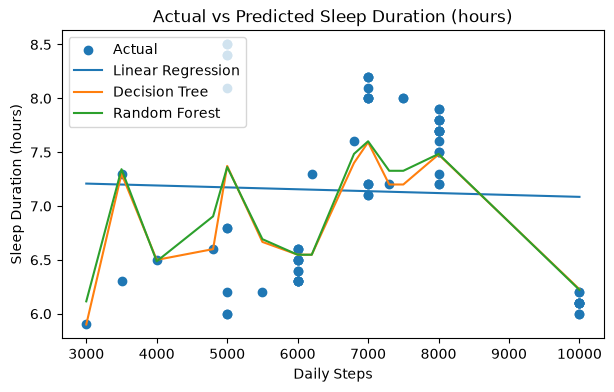

In [ ]:
# Visualization the prediction in Scenario 1
plot_data = pd.DataFrame({
    "Daily Steps": x1_test["Daily Steps"].values,
    "Actual": y1_test.values,
    "Linear Regression": y1_m1_pred,
    "Decision Tree": y1_m2_pred,
    "Random Forest": y1_m3_pred
}).sort_values("Daily Steps")

plt.figure(figsize=(7, 4))
plt.scatter(plot_data["Daily Steps"], plot_data["Actual"], label="Actual")
plt.plot(plot_data["Daily Steps"], plot_data["Linear Regression"], label="Linear Regression")
plt.plot(plot_data["Daily Steps"], plot_data["Decision Tree"], label="Decision Tree")
plt.plot(plot_data["Daily Steps"], plot_data["Random Forest"], label="Random Forest")

plt.xlabel("Daily Steps")
plt.ylabel("Sleep Duration (hours)")
plt.title("Actual vs Predicted Sleep Duration (hours)")
plt.legend()
plt.show()

In [129]:
# Machine Learning Algorithm
# Scenario 2 - Sleep Duration vs Daily Steps & Stress Level & Age
x2 = sleep_data[["Daily Steps", "Stress Level", "Age"]]
y2 = sleep_data["Sleep Duration"]

# Perform random split between the train and test data set. Here we are testing 20% of the data.
x2_train, x2_test, y2_train, y2_test = train_test_split(
    x2, y2, test_size=0.2, random_state=100
)

# Model 4: Decision Tree Regression
model4 = DecisionTreeRegressor(random_state=100)
model4.fit(x2_train, y2_train)
y2_m4_pred = model4.predict(x2_test)
print("R² from Decision Tree Regression:", r2_score(y2_test, y2_m4_pred))
print("RMSE from Decision Tree Regression:", np.sqrt(mean_squared_error(y2_test, y2_m4_pred)))

# Model 5: Random Forest Regression
model5 = RandomForestRegressor(random_state=100)
model5.fit(x2_train, y2_train)
y2_m5_pred = model5.predict(x2_test)
print("R² from Random Forest Regression:", r2_score(y2_test, y2_m5_pred))
print("RMSE from Random Forest Regression:", np.sqrt(mean_squared_error(y2_test, y2_m5_pred)))

# Model 6: Gradient Boosting Regression
model6 = GradientBoostingRegressor(random_state=100)
model6.fit(x2_train, y2_train)
y2_m6_pred = model6.predict(x2_test)
print("R² from Gradient Boosting Regression:", r2_score(y2_test, y2_m6_pred))
print("RMSE from Gradient Boosting Regression:", np.sqrt(mean_squared_error(y2_test, y2_m6_pred)))

R² from Decision Tree Regression: 0.9733132520361053
RMSE from Decision Tree Regression: 0.12952174647119252
R² from Random Forest Regression: 0.9723107406514326
RMSE from Random Forest Regression: 0.13193211793715676
R² from Gradient Boosting Regression: 0.9568923571525434
RMSE from Gradient Boosting Regression: 0.16461598416171516


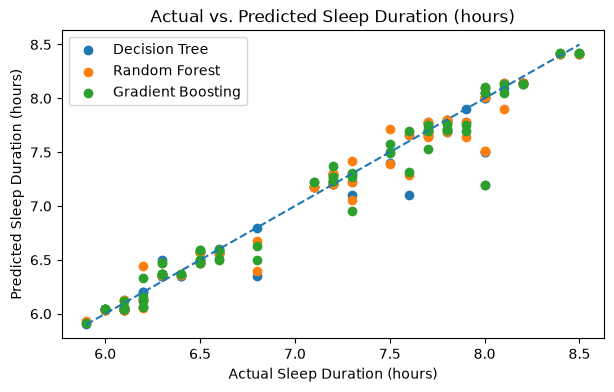

In [ ]:
# Visualization the prediction in Scenario 2
# Using Predicted vs Actual
plt.figure(figsize=(7, 4))

plt.scatter(y2_test, y2_m4_pred, label="Decision Tree")
plt.scatter(y2_test, y2_m5_pred, label="Random Forest")
plt.scatter(y2_test, y2_m6_pred, label="Gradient Boosting")

# Perfect prediction line
plt.plot(
    [y2_test.min(), y2_test.max()],
    [y2_test.min(), y2_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sleep Duration (hours)")
plt.ylabel("Predicted Sleep Duration (hours)")
plt.title("Actual vs. Predicted Sleep Duration (hours)")
plt.legend()
plt.show()